# 선문대학교 컴퓨터공학부
# 2022243101 최완우

### 8.7 텐서플로우로 시작하는 Hello world! = MNIST 예제

In [17]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print('x_train 데이터의 형태 : ', x_train.shape)
print('x_train[0] 데이터의 형태 : ', x_train[0].shape)
print('y_train 데이터의 형태 : ', y_train.shape)

x_train 데이터의 형태 :  (60000, 28, 28)
x_train[0] 데이터의 형태 :  (28, 28)
y_train 데이터의 형태 :  (60000,)


In [18]:
num = x_train[0]
for i in range(28) :
    for j in range(28) :
        print('{:4d}'.format(num[i][j]), end = '')
    print()

   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0
   0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0
   0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0
   0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 182 247 241   0   0   0   0   0   0

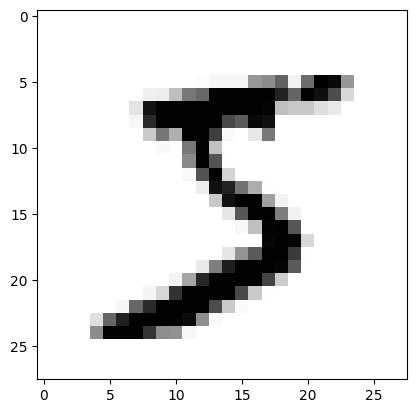

In [19]:
plt.imshow(num, cmap = 'Greys', interpolation = 'nearest')

In [20]:
x_train, x_test = x_train / 255, x_test / 255

model = keras.models.Sequential( [
    keras.layers.Input(shape = (28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation = 'relu'),
    keras.layers.Dense(10, activation = 'softmax'),    
])

model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])
model.fit(x_train, y_train, epochs = 5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9329 - loss: 0.2297
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9718 - loss: 0.0936
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9805 - loss: 0.0628
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9864 - loss: 0.0441
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9896 - loss: 0.0331


In [21]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 610,592 (2.33 MB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 407,062 (1.55 MB)

In [22]:
print('신경망 모델의 학습 결과 : ')
eval_loss, eval_acc = model.evaluate(x_test, y_test)
print('test 데이터의 손실값', eval_loss, 'test 데이터의 정확도', eval_acc)

신경망 모델의 학습 결과 : 
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9790 - loss: 0.0725
test 데이터의 손실값 0.072510726749897 test 데이터의 정확도 0.9789999723434448


In [23]:
import numpy as np

def softmax(a) :
    exp_of_a = np.exp(a)
    sum_exp = np.sum(exp_of_a)
    y = exp_of_a / sum_exp
    return y

a = np.array([0.5, 4.1, 2.5, 5.6, 1.2])
print('신경망의 예측값 : ', a)
print('소프트맥스 함수의 출력 : ', softmax(a))

신경망의 예측값 :  [0.5 4.1 2.5 5.6 1.2]
소프트맥스 함수의 출력 :  [0.00473882 0.17343248 0.03501541 0.77727047 0.00954281]


In [24]:
print('소프트맥스 함수의 최대값 : ', np.max(softmax(a)))

소프트맥스 함수의 최대값 :  0.7772704668966948


In [26]:
a = np.array([0.5, 4.1, 2.5, 5.6, 1.2]) * 2
print('신경망의 예측값 : ', a)
print('소프트맥스 함수의 출력 : ', softmax(a))
print('소프트맥스 함수의 최대값 : ', np.max(softmax(a)))

신경망의 예측값 :  [ 1.   8.2  5.  11.2  2.4]
소프트맥스 함수의 출력 :  [3.53328547e-05 4.73259126e-02 1.92910850e-03 9.50566364e-01
 1.43281791e-04]
소프트맥스 함수의 최대값 :  0.9505663642857384


In [27]:
from keras.utils import to_categorical

data = np.array([0, 1, 2, 3, 4])
print('이코딩할 원본 데이터', data)
encoded = to_categorical(data)
print('원-핫 인코딩된 데이터 : ')
print(encoded)

이코딩할 원본 데이터 [0 1 2 3 4]
원-핫 인코딩된 데이터 : 
[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]


In [28]:
import numpy as np

target = np.array([0, 0, 0, 1, 0])
y_hat = np.array([0.005, 0.173, 0.035, 0.777, 0.01])

def mse(y, t) :
    return ((y - t) ** 2).mean()

print('y_hat과 target과의 오차 : ', mse(y_hat, target))

y_hat과 target과의 오차 :  0.016201599999999997


Text(0, 0.5, 'num of rooms')

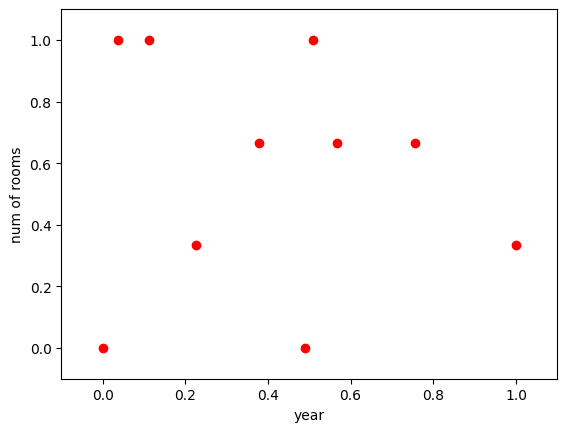

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

yr = np.array([15, 30, 23, 5, 9, 43, 33, 29, 3, 56])
n_rooms = np.array([2, 4, 3, 4, 4, 3, 3, 1, 1, 2])

min_max_scaler = MinMaxScaler()
yr_norm = min_max_scaler.fit_transform(yr[:, np.newaxis])
n_rooms_norm = min_max_scaler.fit_transform(n_rooms[:, np.newaxis])

plt.scatter(yr_norm, n_rooms_norm, c = 'red')
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.xlabel('year')
plt.ylabel('num of rooms')

In [35]:
model = keras.models.Sequential( [
    keras.layers.Flatten(input_shape = (28, 28)),
    keras.layers.Dense(64, activation = 'relu'),
    keras.layers.Dense(64, activation = 'relu'),
    keras.layers.Dense(64, activation = 'relu'),
    keras.layers.Dense(64, activation = 'relu'),
    keras.layers.Dense(64, activation = 'relu'),
    keras.layers.Dense(64, activation = 'relu'),
    keras.layers.Dense(10, activation = 'softmax'),
])

model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])
history = model.fit(x_train, y_train, epochs = 3,
                    validation_data = (x_test, y_test))

C:\Users\최완우\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9099 - loss: 0.2961 - val_accuracy: 0.9526 - val_loss: 0.1525
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9584 - loss: 0.1377 - val_accuracy: 0.9623 - val_loss: 0.1325
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9681 - loss: 0.1085 - val_accuracy: 0.9685 - val_loss: 0.1064


<Axes: >

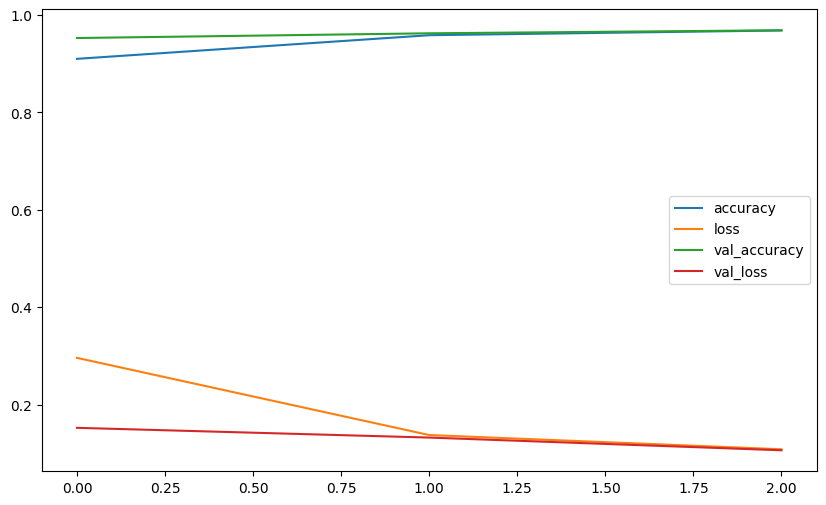

In [36]:
import pandas as pd
pd.DataFrame(history.history).plot(figsize = (10, 6))

### Early Stopping 기능 활용

In [38]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train, x_test = x_train / 255, x_test / 255  # 입력값 정규화

# 층을 추가한 모델 만들기
model = keras.models.Sequential( [
    keras.layers.Input(shape=(28,28)),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation = 'relu'),
    keras.layers.Dense(64, activation = 'relu'),
    keras.layers.Dense(64, activation = 'relu'),
    keras.layers.Dense(10, activation = 'softmax'),
])

from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(patience=5)

model.compile(optimizer='adam',
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])
history = model.fit(x_train, y_train, batch_size=64,
                    epochs=100, validation_split=0.25, callbacks = [early_stopping])

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print('테스트 정확도:', test_acc)

Epoch 1/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8942 - loss: 0.3666 - val_accuracy: 0.9414 - val_loss: 0.1993
Epoch 2/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9523 - loss: 0.1591 - val_accuracy: 0.9567 - val_loss: 0.1495
Epoch 3/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9652 - loss: 0.1156 - val_accuracy: 0.9562 - val_loss: 0.1463
Epoch 4/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9721 - loss: 0.0925 - val_accuracy: 0.9569 - val_loss: 0.1469
Epoch 5/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9768 - loss: 0.0745 - val_accuracy: 0.9665 - val_loss: 0.1142
Epoch 6/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9802 - loss: 0.0611 - val_accuracy: 0.9639 - val_loss: 0.1337
Epoch 7/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9836 - loss: 0.0527 - val_accuracy: 0.9693 - val_loss: 0.1146
Epoch 8/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9861 - loss: 0.0451 - val_accu

<Axes: >

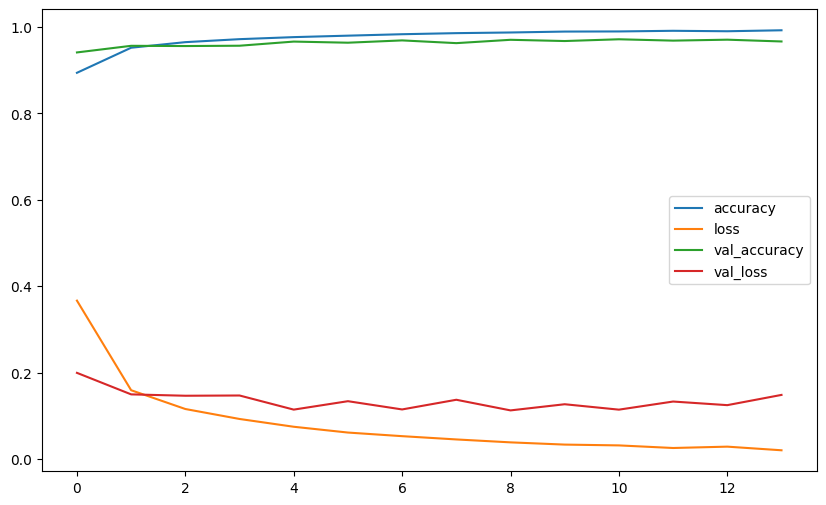

In [39]:
import pandas as pd
pd.DataFrame(history.history).plot(figsize = (10, 6))

In [42]:
data = np.arange(1, 11).reshape(2, 5).astype(np.float32)
print(data)

[[ 1.  2.  3.  4.  5.]
 [ 6.  7.  8.  9. 10.]]


In [43]:
layer = tf.keras.layers.Dropout(.3, input_shape = (2, ))
outputs = layer(data, training = True)
print(outputs)

tf.Tensor(
[[ 1.4285715  0.         4.285714   0.         0.       ]
 [ 8.571428  10.        11.428572  12.857143  14.285715 ]], shape=(2, 5), dtype=float32)


C:\Users\최완우\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\regularization\dropout.py:42: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [45]:
model = keras.models.Sequential( [
    keras.layers.Flatten(input_shape = (28, 28)),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation = 'relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation = 'relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation = 'relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation = 'relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation = 'relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation = 'relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(10, activation = 'softmax'),
])

model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])
history = model.fit(x_train, y_train, epochs = 10,
                    validation_data = (x_test, y_test))

C:\Users\최완우\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7774 - loss: 0.7106 - val_accuracy: 0.9381 - val_loss: 0.2331
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9046 - loss: 0.3603 - val_accuracy: 0.9486 - val_loss: 0.1803
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9202 - loss: 0.3093 - val_accuracy: 0.9576 - val_loss: 0.1605
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9289 - loss: 0.2773 - val_accuracy: 0.9619 - val_loss: 0.1432
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9353 - loss: 0.2498 - val_accuracy: 0.9646 - val_loss: 0.1281
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9378 - loss: 0.2407 - val_accuracy: 0.9663 - val_loss: 0.1297
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9418 - loss: 0.2276 - val_accuracy: 0.9690 - val_loss: 0.1207
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9430 - loss: 0.2242 - 

<Axes: >

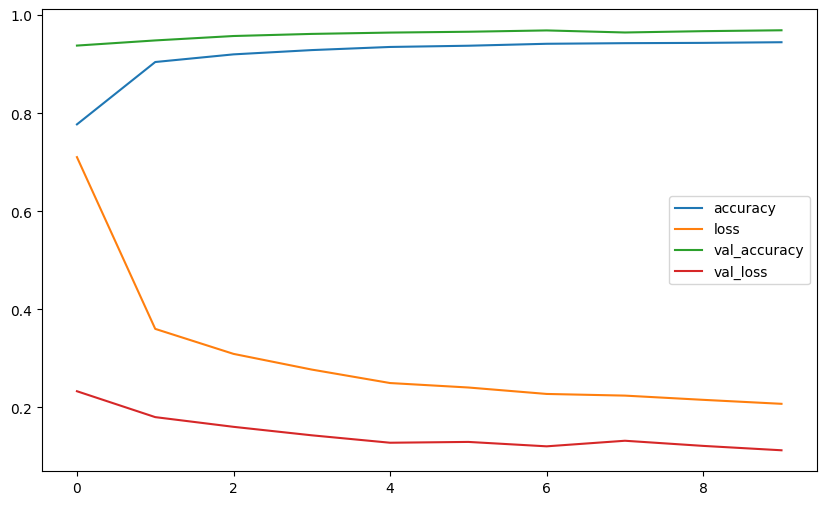

In [46]:
import pandas as pd
pd.DataFrame(history.history).plot(figsize = (10, 6))